In [5]:
import sys 
sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

from propa.rtf.rtf_localisation.zhang_et_al_testcase.zhang_misc import (
    get_estimated_src_pos,
    get_axis_order,
)


import os
import xarray as xr 
import numpy as np
import matplotlib.pyplot as plt 
from skimage.segmentation import clear_border
from skimage import measure
from skimage.measure import label, regionprops
from scipy.ndimage import (
    measurements,
    center_of_mass,
    binary_dilation,
    binary_fill_holes, 
    zoom,
    label,
)
from sklearn.cluster import KMeans
from itertools import combinations
from skimage.filters import sobel
from scipy.spatial import ConvexHull
from scipy.ndimage import gaussian_filter
from sklearn import preprocessing

import matplotlib.pyplot as plt

from skimage.morphology import disk
from skimage.segmentation import watershed
from skimage import data
from skimage.filters import rank
from skimage.util import img_as_ubyte

# from publication.PublicationFigure import PubFigure
# p = PubFigure(disable_backend=False)

In [6]:
# Load data
# # Reduced dataset (debug mode)
# fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\rtf\rtf_localisation\zhang_et_al_testcase\data\from_signal_dx20m_dy20m\snr_0.0dB\loc_zhang_dx20m_dy20m_snr0.0dB_mc1_fullarray_s1_s2_s3_s4_s5_s6.nc"
# Full dataset (cas favorable snr 0 et antenne complète)
# fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\rtf\rtf_localisation\zhang_et_al_testcase\data\backups\rtf_zhang_backup_26032025\data\from_signal_dx20m_dy20m\snr_0.0dB\loc_zhang_dx20m_dy20m_snr0.0dB_mc120_fullarray_s1_s2_s3_s4_s5_s6.nc"

# - 10dB
# fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\rtf\rtf_localisation\zhang_et_al_testcase\data\backups\rtf_zhang_backup_16032025_1600\data\from_signal_dx20m_dy20m\snr_-10.0dB\loc_zhang_dx20m_dy20m_snr-10dB_mc0_fullarray_s1_s2_s3_s4_s5_s6.nc"

# -5dB
# fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\rtf\rtf_localisation\zhang_et_al_testcase\data\backups\rtf_zhang_backup_16032025_1600\data\from_signal_dx20m_dy20m\snr_-5.0dB\loc_zhang_dx20m_dy20m_snr-5dB_mc0_fullarray_s1_s2_s3_s4_s5_s6.nc"

# -10dB

root_seg_data = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\rtf\rtf_localisation\zhang_et_al_testcase\data\segmentation_analysis"

file_names = "loc_zhang_dx20m_dy20m_snr-10.0dB_mc7_fullarray_s1_s2_s3_s4_s5_s6.nc"
ds = xr.open_dataset(os.path.join(root_seg_data, file_names))

In [7]:
ds

<xarray.Dataset> Size: 63kB
Dimensions:    (y: 51, x: 51)
Coordinates:
  * x          (x) float64 408B 3.5e+03 3.52e+03 3.54e+03 ... 4.48e+03 4.5e+03
  * y          (y) float64 408B 6.4e+03 6.42e+03 6.44e+03 ... 7.38e+03 7.4e+03
Data variables:
    theta_rtf  (y, x) float64 21kB ...
    d_rtf      (y, x) float64 21kB ...
    d_gcc      (y, x) float64 21kB ...
Attributes:
    idx_rcv:  [0 1 2 3 4 5]
    snr:      -10.0

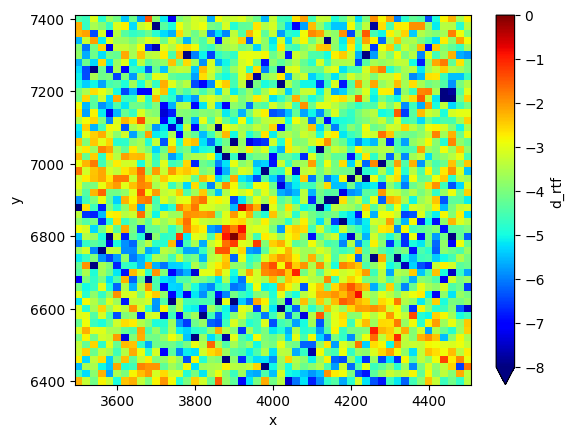

In [8]:
ds.d_rtf.plot(x="x", cmap="jet", vmin=-8)

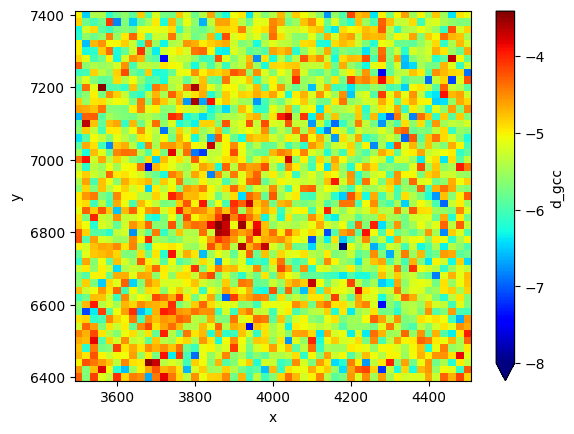

In [9]:
ds.d_gcc.plot(x="x", cmap="jet", vmin=-8)

In [10]:
image_dcf = 10 ** (ds.d_gcc.values / 10)
image_dcf = img_as_ubyte(image_dcf)

image_rtf = 10 ** (ds.d_rtf.values / 10)
image_rtf = img_as_ubyte(image_rtf)

# Première approche : k-means

In [11]:
def apply_kmeans(X, n_clusters):
    # Normalize features
    X_norm = preprocessing.normalize(X).T
    # Apply kmeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto")
    kmeans.fit(X_norm)

    # Get labels
    labels = kmeans.labels_

    return labels

## Features : intensité 

In [12]:
n_clusters = 7
# Kmeans avec seulement les intensités des pixels
X_dcf = image_dcf.flatten()[np.newaxis, :]
X_rtf = image_rtf.flatten()[np.newaxis, :]

In [13]:
X_rtf.shape

(1, 2601)

In [14]:
labels_dcf = apply_kmeans(X_dcf, n_clusters)
labels_rtf = apply_kmeans(X_rtf, n_clusters)

In [15]:
# Reshape labels to 2d arrays 
labels_dcf = labels_dcf.reshape(ds.d_gcc.shape)
labels_rtf = labels_rtf.reshape(ds.d_rtf.shape)

In [16]:
labels_dcf.shape

(51, 51)

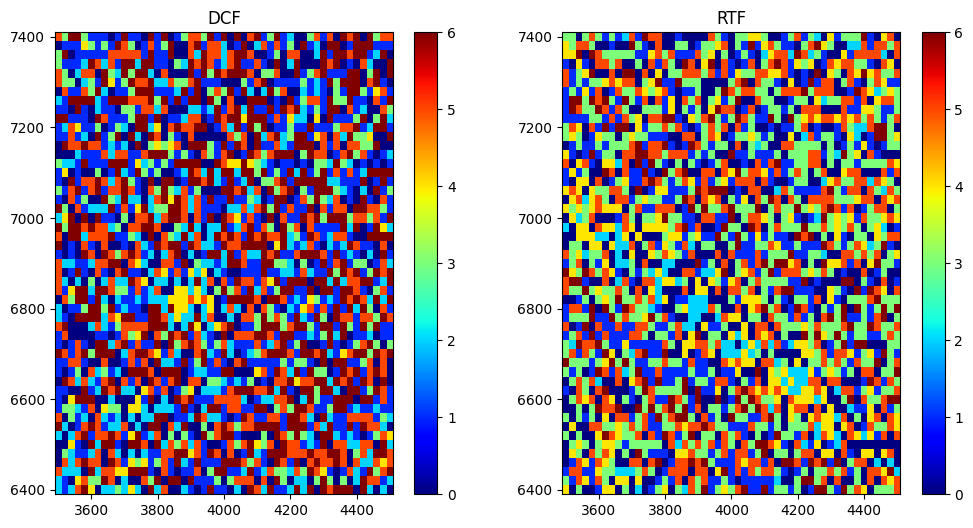

In [17]:
# Plot labels
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
im0 = axs[0].pcolormesh(ds.x, ds.y, labels_dcf, cmap="jet")
plt.colorbar(im0, ax=axs[0])
axs[0].set_title("DCF")

im1 = axs[1].pcolormesh(ds.x, ds.y, labels_rtf, cmap="jet")
axs[1].set_title("RTF")
plt.colorbar(im1, ax=axs[1])

## Feature : intensité avec pré-traitement 

In [18]:
disk_size = 2
image_dcf_smooth = rank.median(image_dcf, disk(disk_size))
image_rtf_smooth = rank.median(image_rtf, disk(disk_size))

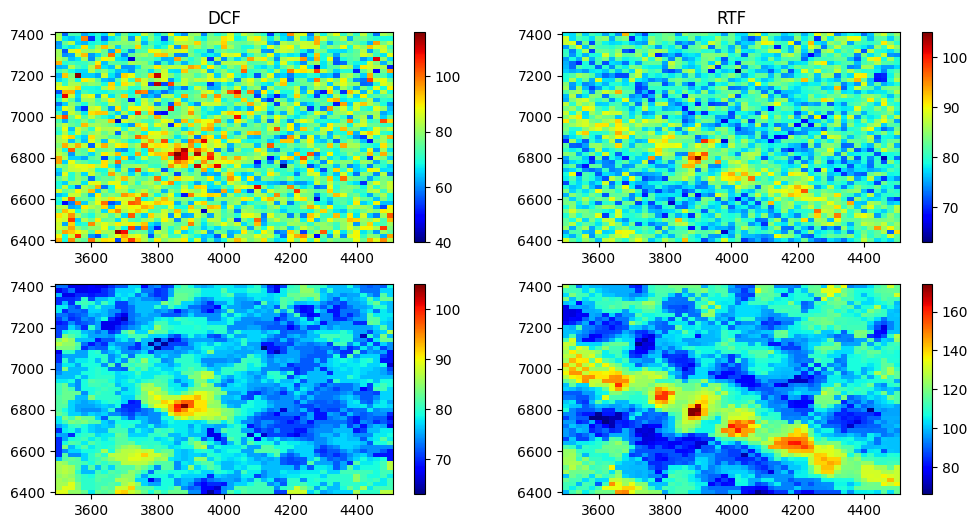

In [19]:
# Plot smoothed images
fig, axs = plt.subplots(2, 2, figsize=(12, 6))
im0 = axs[0, 0].pcolormesh(ds.x, ds.y, image_dcf, cmap="jet")
plt.colorbar(im0, ax=axs[0, 0])
im0 = axs[1, 0].pcolormesh(ds.x, ds.y, image_dcf_smooth, cmap="jet")
plt.colorbar(im0, ax=axs[1, 0])
axs[0, 0].set_title("DCF")

im1 = axs[0, 1].pcolormesh(ds.x, ds.y, image_rtf, cmap="jet")
plt.colorbar(im0, ax=axs[0, 1])
im1 = axs[1, 1].pcolormesh(ds.x, ds.y, image_rtf_smooth, cmap="jet")
axs[0, 1].set_title("RTF")
plt.colorbar(im1, ax=axs[1, 1])

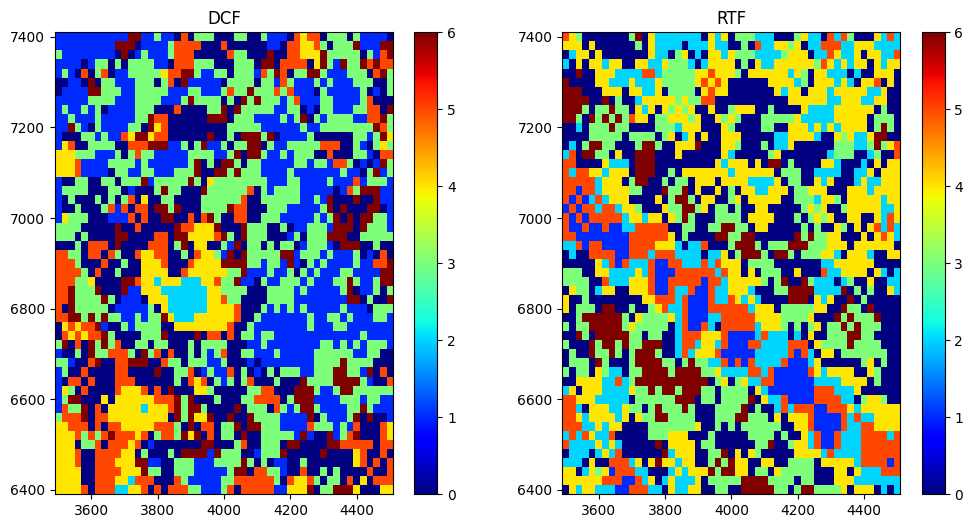

In [20]:
n_clusters = 7
# Kmeans avec seulement les intensités des pixels
X_dcf = image_dcf_smooth.flatten()[np.newaxis, :]
X_rtf = image_rtf_smooth.flatten()[np.newaxis, :]
labels_dcf = apply_kmeans(X_dcf, n_clusters)
labels_rtf = apply_kmeans(X_rtf, n_clusters)
# Reshape labels to 2d arrays
labels_dcf = labels_dcf.reshape(ds.d_gcc.shape)
labels_rtf = labels_rtf.reshape(ds.d_rtf.shape)
# Plot labels
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
im0 = axs[0].pcolormesh(ds.x, ds.y, labels_dcf, cmap="jet")
plt.colorbar(im0, ax=axs[0])
axs[0].set_title("DCF")
im1 = axs[1].pcolormesh(ds.x, ds.y, labels_rtf, cmap="jet")
axs[1].set_title("RTF")
plt.colorbar(im1, ax=axs[1])

## Features : intensité et position

In [21]:
disk_size = 1
image_dcf_smooth = rank.median(image_dcf, disk(disk_size))
image_rtf_smooth = rank.median(image_rtf, disk(disk_size))

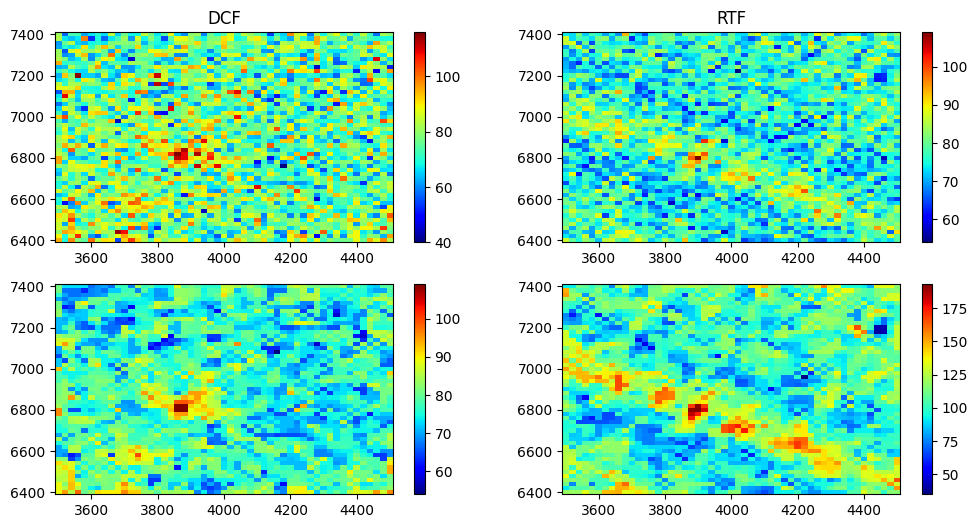

In [22]:
# Plot smoothed images
fig, axs = plt.subplots(2, 2, figsize=(12, 6))
im0 = axs[0, 0].pcolormesh(ds.x, ds.y, image_dcf, cmap="jet")
plt.colorbar(im0, ax=axs[0, 0])
im0 = axs[1, 0].pcolormesh(ds.x, ds.y, image_dcf_smooth, cmap="jet")
plt.colorbar(im0, ax=axs[1, 0])
axs[0, 0].set_title("DCF")

im1 = axs[0, 1].pcolormesh(ds.x, ds.y, image_rtf, cmap="jet")
plt.colorbar(im0, ax=axs[0, 1])
im1 = axs[1, 1].pcolormesh(ds.x, ds.y, image_rtf_smooth, cmap="jet")
axs[0, 1].set_title("RTF")
plt.colorbar(im1, ax=axs[1, 1])

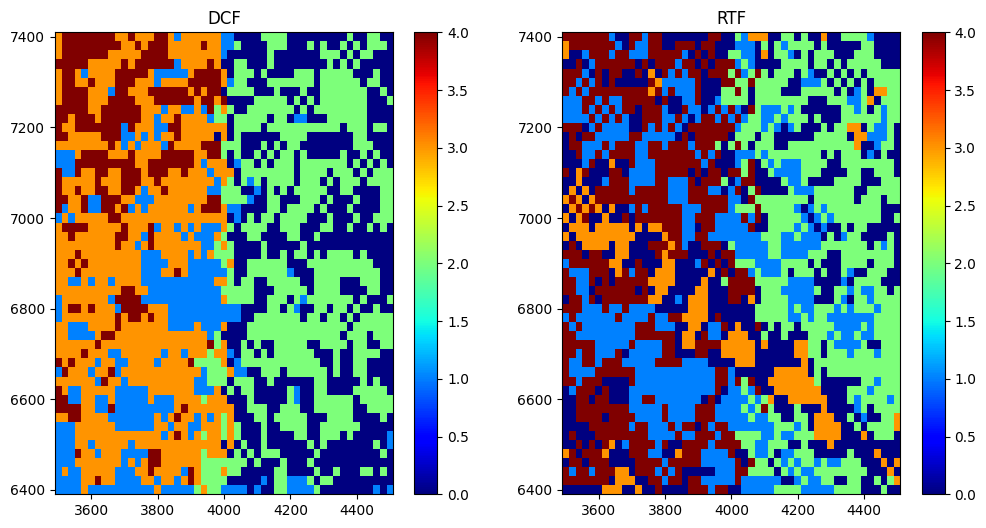

In [23]:
n_clusters = 5
# Extract coords
x_coord, y_coord = np.meshgrid(ds.x.values, ds.y.values)
# Kmeans avec intensités des pixels et coordonnées
X_dcf = np.vstack([x_coord.flatten(), y_coord.flatten(), image_dcf_smooth.flatten()])
X_rtf = np.vstack([x_coord.flatten(), y_coord.flatten(), image_rtf_smooth.flatten()])

labels_dcf = apply_kmeans(X_dcf, n_clusters)
labels_rtf = apply_kmeans(X_rtf, n_clusters)
# Reshape labels to 2d arrays
labels_dcf = labels_dcf.reshape(ds.d_gcc.shape)
labels_rtf = labels_rtf.reshape(ds.d_rtf.shape)
# Plot labels
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
im0 = axs[0].pcolormesh(ds.x, ds.y, labels_dcf, cmap="jet")
plt.colorbar(im0, ax=axs[0])
axs[0].set_title("DCF")
im1 = axs[1].pcolormesh(ds.x, ds.y, labels_rtf, cmap="jet")
axs[1].set_title("RTF")
plt.colorbar(im1, ax=axs[1])

## Masque associé

In [24]:
def get_src_pos_label(amb_surf, labels):
    x_idx, y_idx, _, _ = get_estimated_src_pos(amb_surf=amb_surf, loc_arg="max")
    ax_order = get_axis_order(da=amb_surf, ax_names=["x", "y"])
    idx_tuple = (y_idx, x_idx) if (ax_order["y"] == 0) else (x_idx, y_idx)
    src_hat_class = labels[idx_tuple]
    return src_hat_class

In [25]:
mask_dcf = labels_dcf == get_src_pos_label(amb_surf=ds.d_gcc, labels=labels_dcf)
mask_rtf = labels_rtf == get_src_pos_label(amb_surf=ds.d_rtf, labels=labels_rtf)

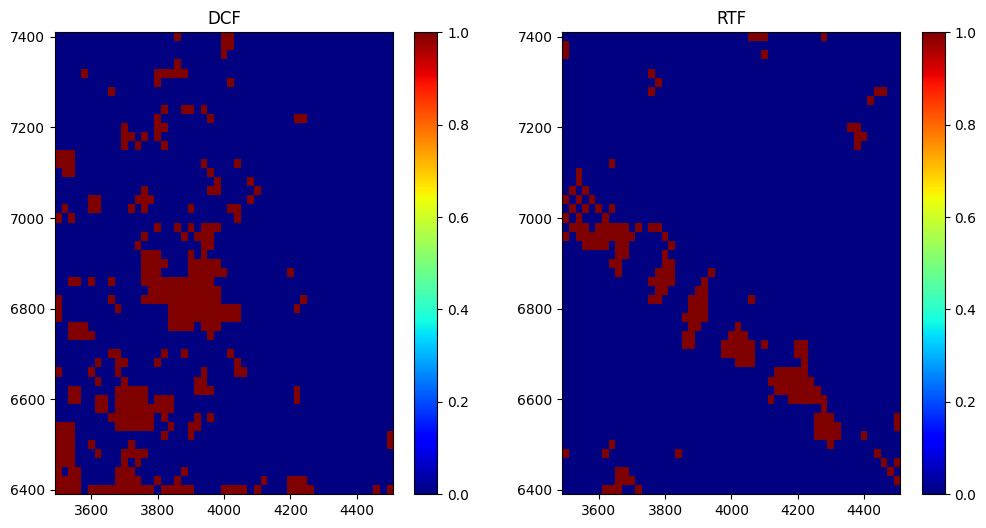

In [26]:
# Plot masks
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
im0 = axs[0].pcolormesh(ds.x, ds.y, mask_dcf, cmap="jet")
plt.colorbar(im0, ax=axs[0])
axs[0].set_title("DCF")

im1 = axs[1].pcolormesh(ds.x, ds.y, mask_rtf, cmap="jet")
axs[1].set_title("RTF")
plt.colorbar(im1, ax=axs[1])

In [27]:
# New labels to get the region of interest
mask_labeled_dcf, nlabel_dcf = label(mask_dcf)
mask_labeled_rtf, nlabel_dcf = label(mask_rtf)

In [28]:
mask_labeled_dcf

array([[1, 1, 1, ..., 7, 0, 8],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

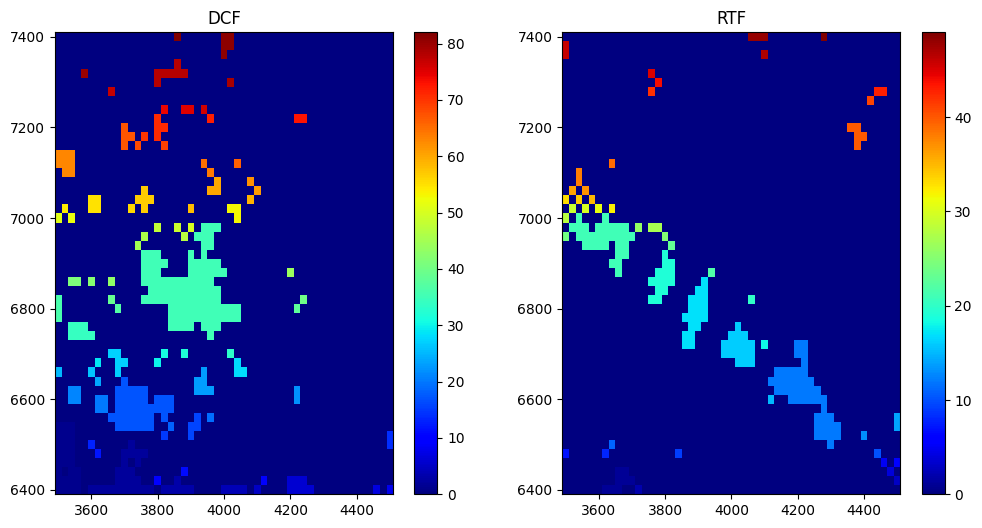

In [29]:
# Plot labeled masks
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
im0 = axs[0].pcolormesh(ds.x, ds.y, mask_labeled_dcf, cmap="jet")
plt.colorbar(im0, ax=axs[0])
axs[0].set_title("DCF")

im1 = axs[1].pcolormesh(ds.x, ds.y, mask_labeled_rtf, cmap="jet")
axs[1].set_title("RTF")
plt.colorbar(im1, ax=axs[1])

In [30]:
# Get labels of the region of interest
label_dcf = get_src_pos_label(amb_surf=ds.d_gcc, labels=mask_labeled_dcf)
label_rtf = get_src_pos_label(amb_surf=ds.d_rtf, labels=mask_labeled_rtf)

In [31]:
label_rtf

17

In [32]:
# Create new masks with only the region of interest
mask_dcf_new = mask_labeled_dcf == label_dcf
mask_rtf_new = mask_labeled_rtf == label_rtf

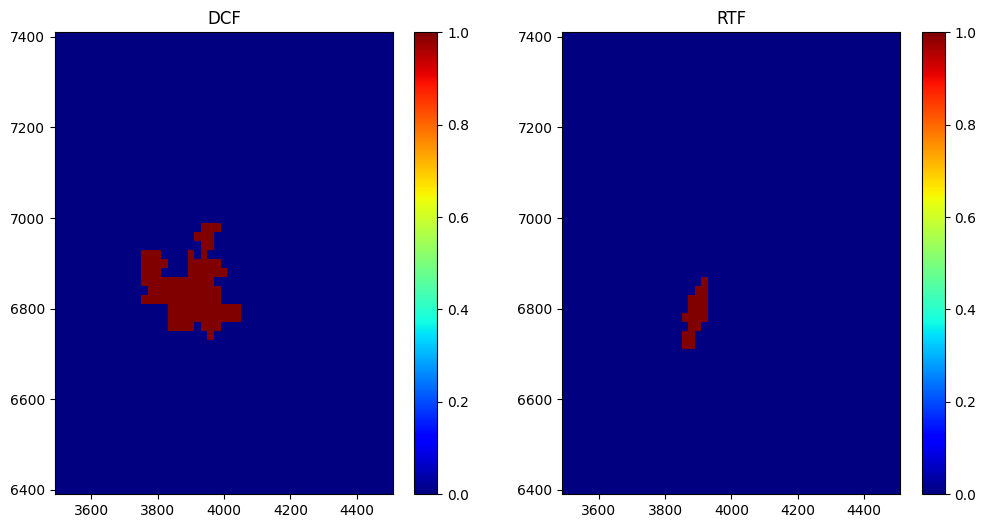

In [33]:
# Plot masks
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
im0 = axs[0].pcolormesh(ds.x, ds.y, mask_dcf_new, cmap="jet")
plt.colorbar(im0, ax=axs[0])
axs[0].set_title("DCF")

im1 = axs[1].pcolormesh(ds.x, ds.y, mask_rtf_new, cmap="jet")
axs[1].set_title("RTF")
plt.colorbar(im1, ax=axs[1])

### Post-traitement des masques pour s'assurer d'avoir pris tous les pixels et qu'il n'y ai pas de trous 

In [34]:
# Remove holes
mask_dcf_new = binary_fill_holes(mask_dcf_new)
mask_rtf_new = binary_fill_holes(mask_rtf_new)

In [35]:
# Expand regions
mask_dcf_new = binary_dilation(mask_dcf_new, iterations=2)
mask_rtf_new = binary_dilation(mask_rtf_new, iterations=2)

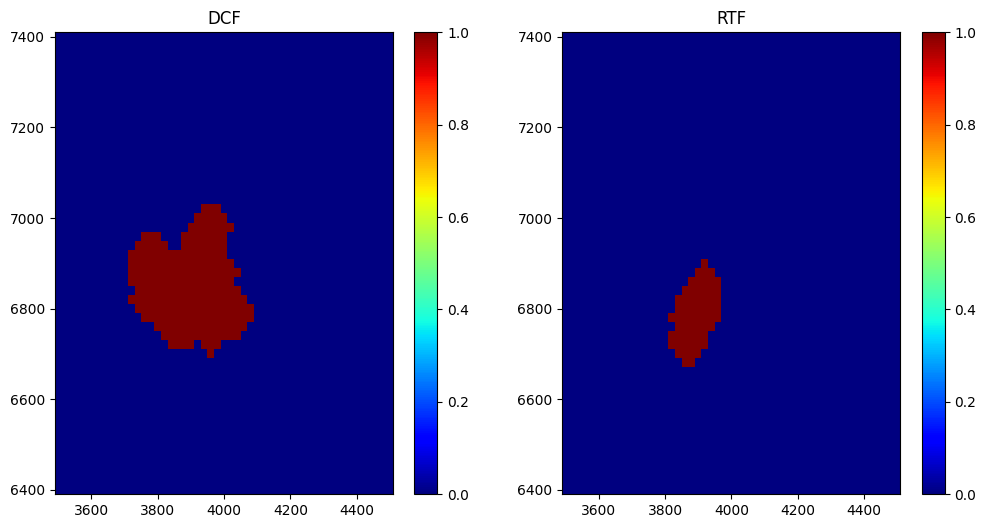

In [36]:
# Plot expanded masks
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
im0 = axs[0].pcolormesh(ds.x, ds.y, mask_dcf_new, cmap="jet")
plt.colorbar(im0, ax=axs[0])
axs[0].set_title("DCF")

im1 = axs[1].pcolormesh(ds.x, ds.y, mask_rtf_new, cmap="jet")
axs[1].set_title("RTF")
plt.colorbar(im1, ax=axs[1])

In [37]:
def main_lobe_contours(amb_surf, mask):
    x_idx, y_idx, _, _ = get_estimated_src_pos(amb_surf=amb_surf, loc_arg="max")
    ax_order = get_axis_order(da=amb_surf, ax_names=["x", "y"])

    # Find contours of src_hat_class and select the contour corresponding to the estimated position
    contours = measure.find_contours(mask, level=0.5)
    for contour in contours:
        # Check if src_hat is within the contour
        idx_x_min = np.min(contour[:, ax_order["x"]].astype(int))
        idx_x_max = np.max(contour[:, ax_order["x"]].astype(int))
        idx_y_min = np.min(contour[:, ax_order["y"]].astype(int))
        idx_y_max = np.max(contour[:, ax_order["y"]].astype(int))
        if (idx_x_min <= x_idx <= idx_x_max) and (idx_y_min <= y_idx <= idx_y_max):
            break

    return contour

In [38]:
ax_order = get_axis_order(da=ds.d_gcc, ax_names=["x", "y"])
contour_dcf = main_lobe_contours(amb_surf=ds.d_gcc, mask=mask_dcf_new)
contour_rtf = main_lobe_contours(amb_surf=ds.d_rtf, mask=mask_rtf_new)

In [39]:
contour_dcf.shape

(85, 2)

Text(0.5, 1.0, 'Smooth RTF')

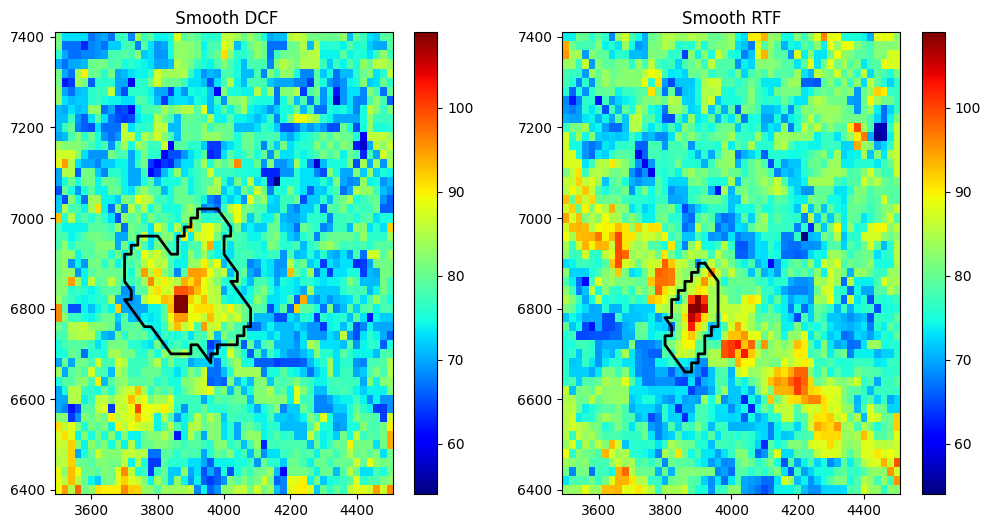

In [40]:
# Plot original image and contour
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
im0 = axs[0].pcolormesh(ds.x, ds.y, image_dcf_smooth, cmap="jet")
plt.colorbar(im0, ax=axs[0])
axs[0].plot(
    ds["x"].values[contour_dcf[:, ax_order["x"]].astype(int)],
    ds["y"].values[contour_dcf[:, ax_order["y"]].astype(int)],
    color="k",
    linewidth=2,
    label="Contour",
)
axs[0].set_title(" Smooth DCF")

im1 = axs[1].pcolormesh(ds.x, ds.y, image_rtf_smooth, cmap="jet")
plt.colorbar(im0, ax=axs[1])
axs[1].plot(
    ds["x"].values[contour_rtf[:, ax_order["x"]].astype(int)],
    ds["y"].values[contour_rtf[:, ax_order["y"]].astype(int)],
    color="k",
    linewidth=2,
    label="Contour",
)
axs[1].set_title("Smooth RTF")

Text(0.5, 1.0, 'RTF')

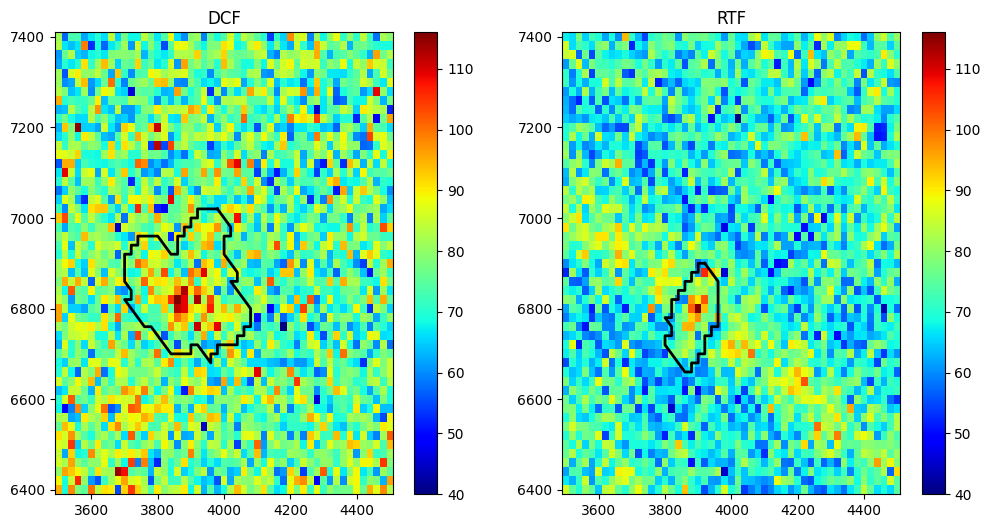

In [41]:
# Plot contour on original image
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
im0 = axs[0].pcolormesh(ds.x, ds.y, image_dcf, cmap="jet")
plt.colorbar(im0, ax=axs[0])
axs[0].plot(
    ds["x"].values[contour_dcf[:, ax_order["x"]].astype(int)],
    ds["y"].values[contour_dcf[:, ax_order["y"]].astype(int)],
    color="k",
    linewidth=2,
    label="Contour",
)
axs[0].set_title("DCF")

im1 = axs[1].pcolormesh(ds.x, ds.y, image_rtf, cmap="jet")
plt.colorbar(im0, ax=axs[1])
axs[1].plot(
    ds["x"].values[contour_rtf[:, ax_order["x"]].astype(int)],
    ds["y"].values[contour_rtf[:, ax_order["y"]].astype(int)],
    color="k",
    linewidth=2,
    label="Contour",
)
axs[1].set_title("RTF")

# Label from scikit.measure

In [42]:
labels_dcf_new, n_features_dcf = label(labels_dcf)
labels_rtf_new, n_features_rtf = label(labels_rtf)

In [43]:
labels_dcf_new.shape

(51, 51)

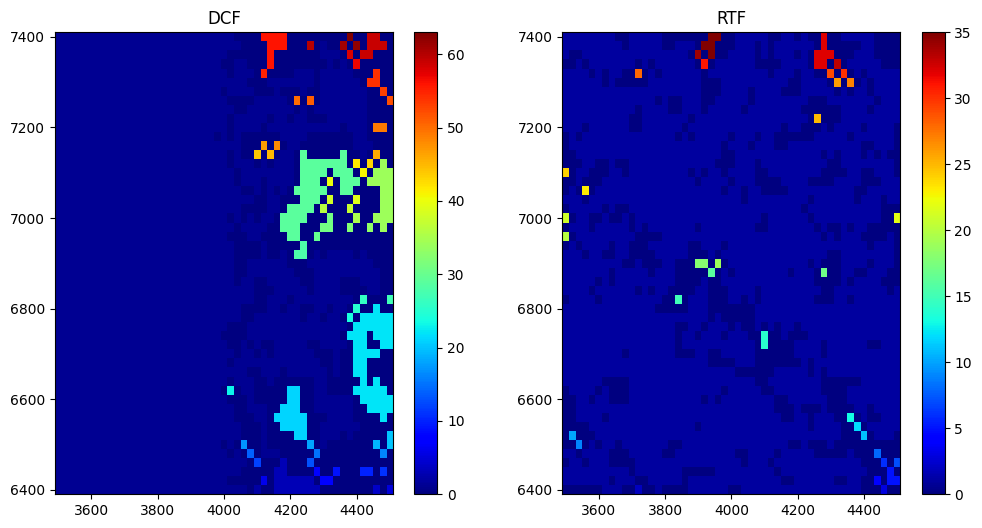

In [44]:
# Plot new labels
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
im0 = axs[0].pcolormesh(ds.x, ds.y, labels_dcf_new, cmap="jet")
plt.colorbar(im0, ax=axs[0])
axs[0].set_title("DCF")

im1 = axs[1].pcolormesh(ds.x, ds.y, labels_rtf_new, cmap="jet")
axs[1].set_title("RTF")
plt.colorbar(im1, ax=axs[1])

## Watershed (Scikit-image)

In [45]:
disk_size = 2
image_dcf_smooth = rank.median(image_dcf, disk(disk_size))
image_rtf_smooth = rank.median(image_rtf, disk(disk_size))

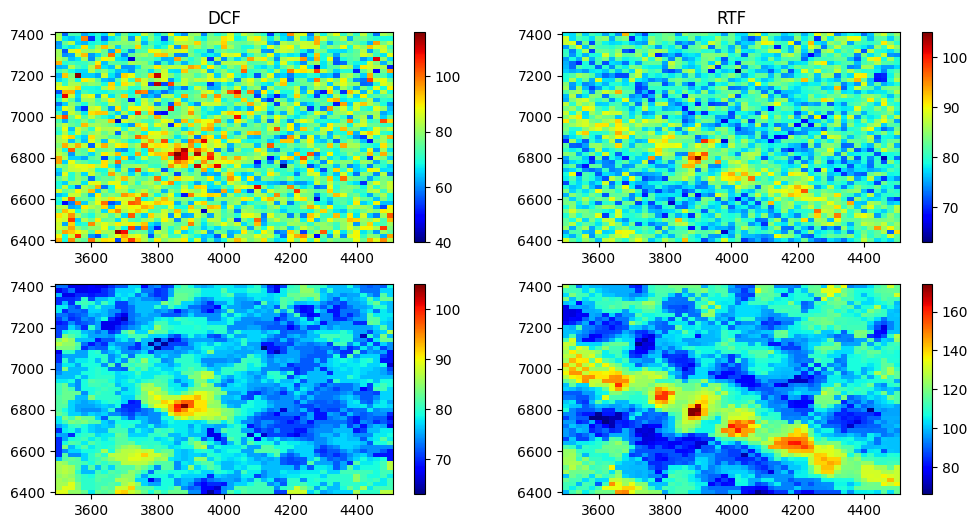

In [46]:
# Plot smoothed images
fig, axs = plt.subplots(2, 2, figsize=(12, 6))
im0 = axs[0, 0].pcolormesh(ds.x, ds.y, image_dcf, cmap="jet")
plt.colorbar(im0, ax=axs[0, 0])
im0 = axs[1, 0].pcolormesh(ds.x, ds.y, image_dcf_smooth, cmap="jet")
plt.colorbar(im0, ax=axs[1, 0])
axs[0, 0].set_title("DCF")

im1 = axs[0, 1].pcolormesh(ds.x, ds.y, image_rtf, cmap="jet")
plt.colorbar(im0, ax=axs[0, 1])
im1 = axs[1, 1].pcolormesh(ds.x, ds.y, image_rtf_smooth, cmap="jet")
axs[0, 1].set_title("RTF")
plt.colorbar(im1, ax=axs[1, 1])

In [47]:
grad_dcf = rank.gradient(image_dcf_smooth, disk(5))
grad_rtf = rank.gradient(image_rtf_smooth, disk(5))

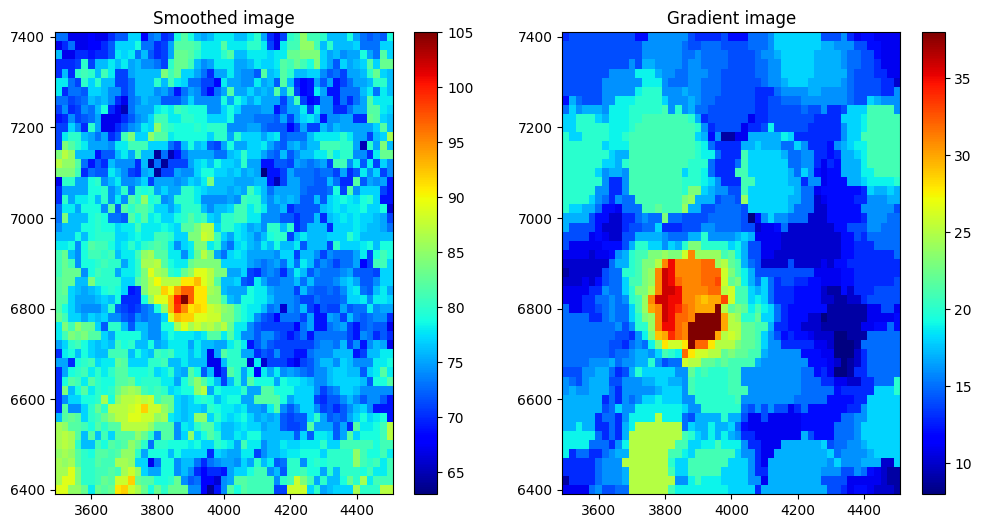

In [48]:
# Plot gradient
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
im0 = axs[0].pcolormesh(ds.x, ds.y, image_dcf_smooth, cmap="jet")
axs[0].set_title("Smoothed image")
plt.colorbar(im0, ax=axs[0])
im = axs[1].pcolormesh(ds.x, ds.y, grad_dcf, cmap="jet")
axs[1].set_title("Gradient image")
plt.colorbar(im, ax=axs[1])

In [50]:
# find continuous region (low gradient -
# where less than 10 for this image) --> markers
# disk(5) is used here to get a more smooth image
markers = grad_dcf < 5
markers = label(markers)[0]

In [51]:
markers.shape

(51, 51)

In [52]:
# local gradient (disk(2) is used to keep edges thin)
gradient = rank.gradient(image_dcf_smooth, disk(2))

In [53]:
# process the watershed
labels = watershed(gradient, 10)

Text(0.5, 0.98, 'DCF')

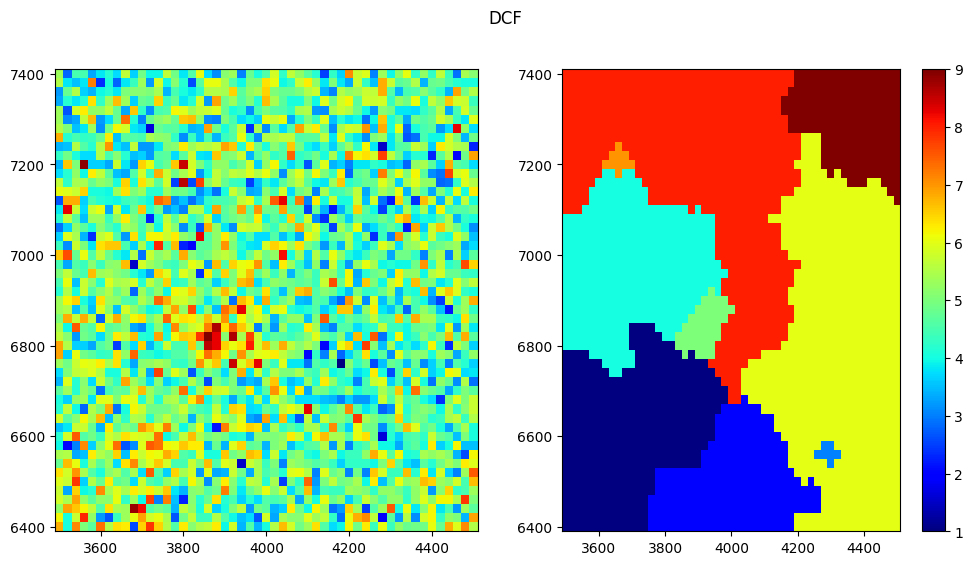

In [54]:
# Plot results
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
im0 = axs[0].pcolormesh(ds.x, ds.y, image_dcf, cmap="jet")
im = axs[1].pcolormesh(ds.x, ds.y, labels, cmap="jet")
plt.colorbar(im, ax=axs[1])
plt.suptitle("DCF")


# Etude de la méthode retenue pour différent SNR de -10 dB à 0 dB 
Les principales étapes sont : 
-   Lissage de la surface d'ambiguité 
-   Kmeans sur la surface lissée (intensité et positions)
-   Définition du masque associé au label contenant le position de la source 
-   Association d'un label à chaque zone du masque 
-   Définition du masque associé au label de la zone contenant la position de la source 
-   Dilatation du masque pour éviter les trous 


In [62]:
root_seg_data = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\rtf\rtf_localisation\zhang_et_al_testcase\data\segmentation_analysis"

snrs = [-16, -14, -12, -10, -8, -6, -4, -2, 0]
file_names = {
    -16: "loc_zhang_dx20m_dy20m_snr-16.0dB_mc0_fullarray_s1_s2_s3_s4_s5_s6.nc",
    -14: "loc_zhang_dx20m_dy20m_snr-14.0dB_mc0_fullarray_s1_s2_s3_s4_s5_s6.nc",
    -12: "loc_zhang_dx20m_dy20m_snr-12.0dB_mc0_fullarray_s1_s2_s3_s4_s5_s6.nc",
    -10: "loc_zhang_dx20m_dy20m_snr-10.0dB_mc7_fullarray_s1_s2_s3_s4_s5_s6.nc",
    -8: "loc_zhang_dx20m_dy20m_snr-8.0dB_mc0_fullarray_s1_s2_s3_s4_s5_s6.nc",
    -6: "loc_zhang_dx20m_dy20m_snr-6.0dB_mc0_fullarray_s1_s2_s3_s4_s5_s6.nc",
    -4: "loc_zhang_dx20m_dy20m_snr-4.0dB_mc0_fullarray_s1_s2_s3_s4_s5_s6.nc",
    -2: "loc_zhang_dx20m_dy20m_snr-2.0dB_mc0_fullarray_s1_s2_s3_s4_s5_s6.nc",
    0: "loc_zhang_dx20m_dy20m_snr0.0dB_mc2_fullarray_s1_s2_s3_s4_s5_s6.nc",
}

# fpath = os.path.join(root_seg_data, fname)

## Méthode du coude pour déterminer le nombre de clusters optimal 

Approche non concluante -> pas de coude dans les graphes d'inertie 

In [56]:
def get_inertias(X, n_clusters):
    # Normalize features
    X_norm = preprocessing.normalize(X).T
    # Apply kmeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto")
    kmeans.fit(X_norm)
    inertia = kmeans.inertia_

    return inertia

In [57]:
# Définition du nombre de cluster à utiliser
fpath = os.path.join(root_seg_data, file_names[-8])
ds = xr.open_dataset(fpath)

image_dcf = 10 ** (ds.d_gcc.values / 10)
image_dcf = img_as_ubyte(image_dcf)

image_rtf = 10 ** (ds.d_rtf.values / 10)
image_rtf = img_as_ubyte(image_rtf)

# 1) Apply filter to smooth images
disk_size = 1
image_dcf_smooth = rank.median(image_dcf, disk(disk_size))
image_rtf_smooth = rank.median(image_rtf, disk(disk_size))

# 2) Apply kmeans to smooth images: features = intensities + coordinates
# Extract coords
x_coord, y_coord = np.meshgrid(ds.x.values, ds.y.values)
X_dcf = np.vstack([x_coord.flatten(), y_coord.flatten(), image_dcf_smooth.flatten()])
X_rtf = np.vstack([x_coord.flatten(), y_coord.flatten(), image_rtf_smooth.flatten()])

inertias = {"dcf": [], "rtf":[]}        # Variance 

for i in range(1, 11):
    inertia_dcf = get_inertias(X_dcf, i)
    inertias["dcf"].append(inertia_dcf)

    inertia_rtf = get_inertias(X_rtf, i)
    inertias["rtf"].append(inertia_rtf)


Text(0, 0.5, 'Inertia')

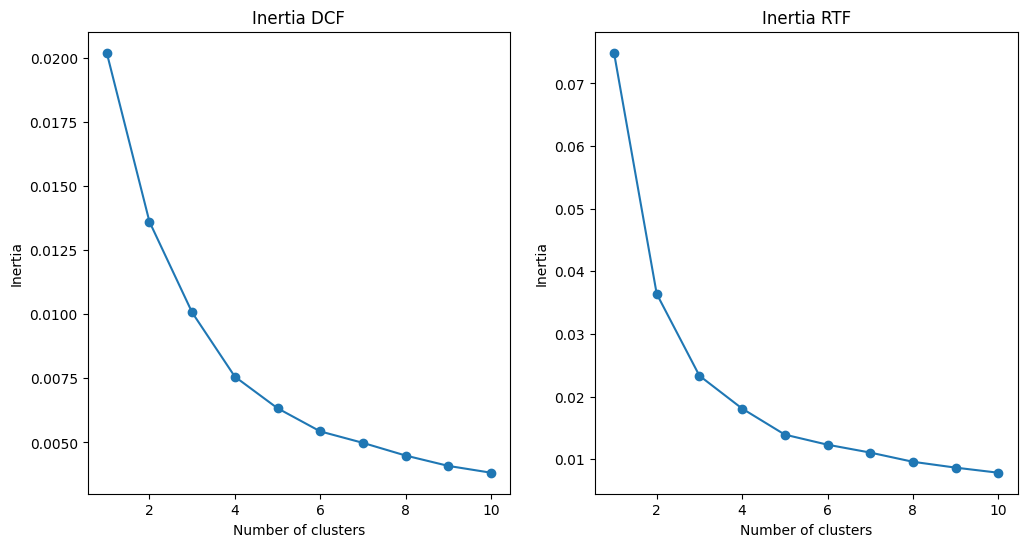

In [58]:
# Plot inertias 
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].plot(range(1, 11), inertias["dcf"], marker="o")
axs[0].set_title("Inertia DCF")
axs[0].set_xlabel("Number of clusters")
axs[0].set_ylabel("Inertia")
axs[1].plot(range(1, 11), inertias["rtf"], marker="o")
axs[1].set_title("Inertia RTF")
axs[1].set_xlabel("Number of clusters")
axs[1].set_ylabel("Inertia")

In [59]:
def process_single_snr(fname):
    fpath = os.path.join(root_seg_data, fname)
    ds = xr.open_dataset(fpath)

    # 0) Convert to image like arrays to use skimage
    image_dcf = 10 ** (ds.d_gcc.values / 10)
    image_dcf = img_as_ubyte(image_dcf)

    image_rtf = 10 ** (ds.d_rtf.values / 10)
    image_rtf = img_as_ubyte(image_rtf)

    # 1) Apply filter to smooth images
    disk_size = 1
    image_dcf_smooth = rank.median(image_dcf, disk(disk_size))
    image_rtf_smooth = rank.median(image_rtf, disk(disk_size))

    # 2) Apply kmeans to smooth images: features = intensities + coordinates
    n_clusters = 4
    # Extract coords
    x_coord, y_coord = np.meshgrid(ds.x.values, ds.y.values)
    X_dcf = np.vstack([x_coord.flatten(), y_coord.flatten(), image_dcf_smooth.flatten()])
    X_rtf = np.vstack([x_coord.flatten(), y_coord.flatten(), image_rtf_smooth.flatten()])

    labels_dcf = apply_kmeans(X_dcf, n_clusters)
    labels_rtf = apply_kmeans(X_rtf, n_clusters)
    # Reshape labels to 2d arrays
    labels_dcf_2d = labels_dcf.reshape(ds.d_gcc.shape)
    labels_rtf_2d = labels_rtf.reshape(ds.d_rtf.shape)

    # 3) Get src position label
    mask_dcf = labels_dcf_2d == get_src_pos_label(
        amb_surf=ds.d_gcc, labels=labels_dcf_2d
    )
    mask_rtf = labels_rtf_2d == get_src_pos_label(
        amb_surf=ds.d_rtf, labels=labels_rtf_2d
    )

    # 4) Assign labels to the different regions of the masks
    mask_labeled_dcf, nlabel_dcf = label(mask_dcf)
    mask_labeled_rtf, nlabel_dcf = label(mask_rtf)
    # Get labels of the region of interest
    label_dcf = get_src_pos_label(amb_surf=ds.d_gcc, labels=mask_labeled_dcf)
    label_rtf = get_src_pos_label(amb_surf=ds.d_rtf, labels=mask_labeled_rtf)

    # 5) Create new masks with only the region of interest
    mask_dcf_new = mask_labeled_dcf == label_dcf
    mask_rtf_new = mask_labeled_rtf == label_rtf

    # 6) Post process masks to remove holes and expand regions
    # Remove holes
    mask_dcf_postprocessed = binary_fill_holes(mask_dcf_new)
    mask_rtf_postprocessed = binary_fill_holes(mask_rtf_new)
    # Expand regions
    mask_dcf_postprocessed = binary_dilation(mask_dcf_postprocessed, iterations=3)
    mask_rtf_postprocessed = binary_dilation(mask_rtf_postprocessed, iterations=3)

    # 7) Get the main lobe contours
    ax_order = get_axis_order(da=ds.d_gcc, ax_names=["x", "y"])
    contour_dcf = main_lobe_contours(amb_surf=ds.d_gcc, mask=mask_dcf_postprocessed)
    contour_rtf = main_lobe_contours(amb_surf=ds.d_rtf, mask=mask_rtf_postprocessed)

    # Store all the results in a dictionary
    results = {
        "dcf":{
            "image": image_dcf,
            "image_smooth": image_dcf_smooth,
            "labels": labels_dcf_2d,
            "mask": mask_dcf,
            "mask_labeled": mask_labeled_dcf,
            "mask_new": mask_dcf_new,
            "mask_postprocessed": mask_dcf_postprocessed,
            "contour": contour_dcf
        },
        "rtf":{
            "image": image_rtf,
            "image_smooth": image_rtf_smooth,
            "labels": labels_rtf_2d,
            "mask": mask_rtf,
            "mask_labeled": mask_labeled_rtf,
            "mask_new": mask_rtf_new,
            "mask_postprocessed": mask_rtf_postprocessed,
            "contour": contour_rtf
        },
        "ax_order": ax_order,
    }

    return results

In [60]:
file_names

{-16: 'loc_zhang_dx20m_dy20m_snr-16.0dB_mc7_fullarray_s1_s2_s3_s4_s5_s6.nc',
 -14: 'loc_zhang_dx20m_dy20m_snr-14.0dB_mc7_fullarray_s1_s2_s3_s4_s5_s6.nc',
 -12: 'loc_zhang_dx20m_dy20m_snr-12.0dB_mc7_fullarray_s1_s2_s3_s4_s5_s6.nc',
 -10: 'loc_zhang_dx20m_dy20m_snr-10.0dB_mc7_fullarray_s1_s2_s3_s4_s5_s6.nc',
 -8: 'loc_zhang_dx20m_dy20m_snr-8.0dB_mc0_fullarray_s1_s2_s3_s4_s5_s6.nc',
 -6: 'loc_zhang_dx20m_dy20m_snr-6.0dB_mc0_fullarray_s1_s2_s3_s4_s5_s6.nc',
 -4: 'loc_zhang_dx20m_dy20m_snr-4.0dB_mc0_fullarray_s1_s2_s3_s4_s5_s6.nc',
 -2: 'loc_zhang_dx20m_dy20m_snr-2.0dB_mc0_fullarray_s1_s2_s3_s4_s5_s6.nc',
 0: 'loc_zhang_dx20m_dy20m_snr0.0dB_mc2_fullarray_s1_s2_s3_s4_s5_s6.nc'}

In [63]:
fname = file_names[snrs[0]]
segmentation_step_data = process_single_snr(fname=fname)

In [64]:
def process_mutli_snr(file_names):
    results = {}
    snrs = list(file_names.keys())
    for snr, fname in zip(snrs, file_names.values()):
        results[snr] = process_single_snr(fname=fname)
    return results

In [65]:
segmentation_results = process_mutli_snr(file_names=file_names)
# Load one dataset to get extra data x and y 
fpath = os.path.join(root_seg_data, file_names[snrs[0]])
ds = xr.open_dataset(fpath)

In [66]:
def plot_segmentation_process(segmentation_results):
    root_img = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\img\illustration\rtf\rtf_localisation\zhang_et_al_2023\mainlobe_estimation_process"
    snrs = list(segmentation_results.keys())
    methods = list(segmentation_results[snrs[0]].keys())

    
    for meth in methods[:-1]: 
        steps = list(segmentation_results[snrs[0]][meth].keys())
        # Create figure: one row per step and one colon per snr
        im = []
        fig, axs = plt.subplots(len(steps), len(snrs), figsize=(12, 6))
        for i, snr in enumerate(snrs):
            axs[0, i].set_title(f"{snr} dB")
            # Get the data
            data = segmentation_results[snr][meth]
            for j, step in enumerate(steps):
                # print(snr, step)
                if i == 0:
                    axs[j, 0].set_ylabel(f"step {j}")
                else:
                    # Remove y ticks for readability
                    axs[j, i].set_yticks([])

                
                if j == len(steps) - 1:
                    axs[j, i].set_xlabel("x")
                else:
                    # Remove x ticks
                    axs[j, i].set_xticks([])

                if step == "contour":
                    ax_order = segmentation_results[snr]["ax_order"]
                    axs[j, i].pcolormesh(ds.x, ds.y, data["image"], cmap="jet")
                    axs[j, i].plot(
                        ds["x"].values[data[step][:, ax_order["x"]].astype(int)],
                        ds["y"].values[data[step][:, ax_order["y"]].astype(int)],
                        color="k",
                        linewidth=2,
                        # label="Contour",
                    )
                    pass
                else:
                    axs[j, i].pcolormesh(ds.x, ds.y, data[step], cmap="jet")    
                    # im.append(im_ij)

        fpath = os.path.join(root_img, f"mainlobe_estimation_process_{meth}.png")
        plt.savefig(fpath)

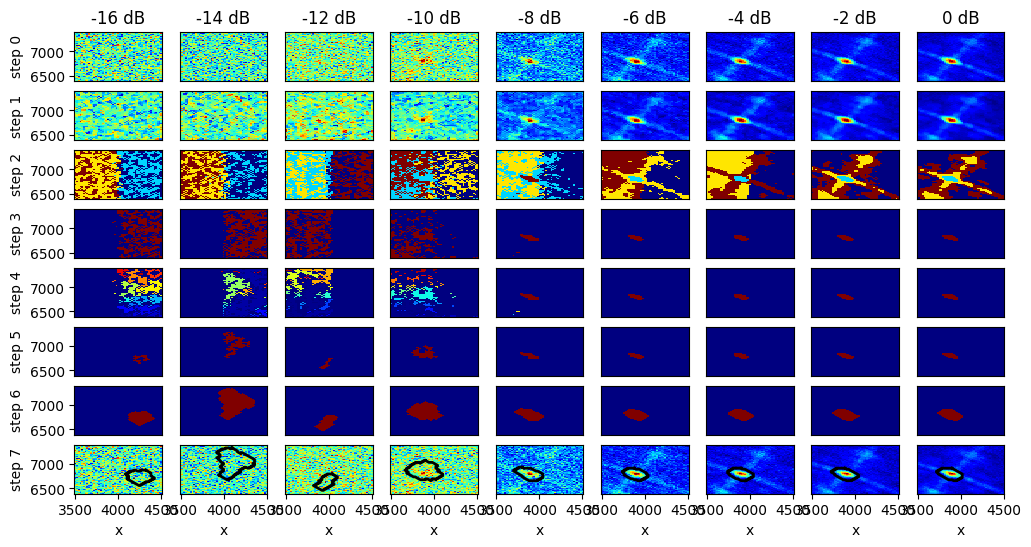

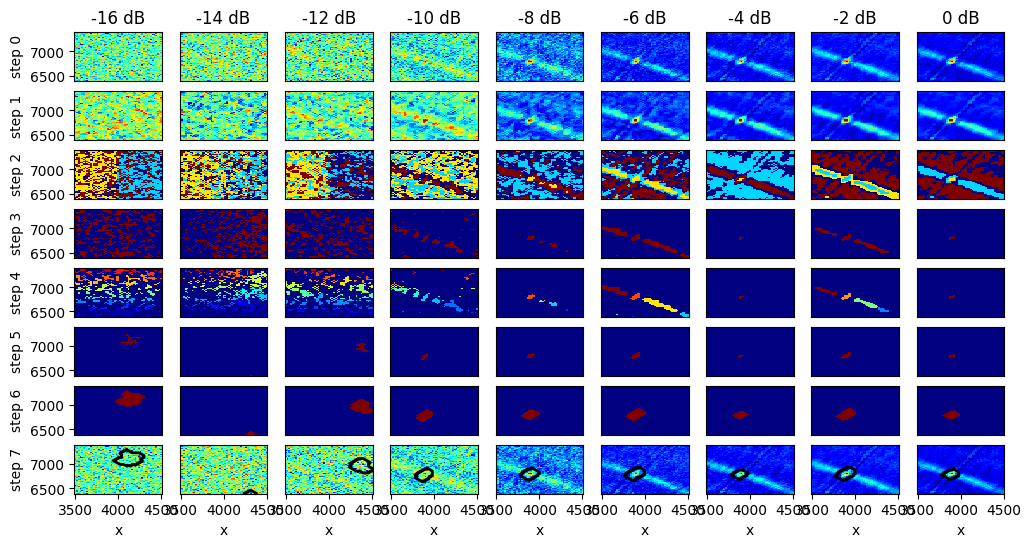

In [67]:
plot_segmentation_process(segmentation_results)